In [1]:
import numpy as np

import sys
sys.path.append('./src')

Coordinates:
[[67.95245991 15.15043835]
 [13.21230531 72.89633762]
 [77.76630775 54.852257  ]
 [70.00941152 78.74446557]]

Distance Matrix:
[[ 0.         79.56804263 40.89677265 63.62728461]
 [79.56804263  0.         67.02841245 57.09738939]
 [40.89677265 67.02841245  0.         25.11985409]
 [63.62728461 57.09738939 25.11985409  0.        ]]


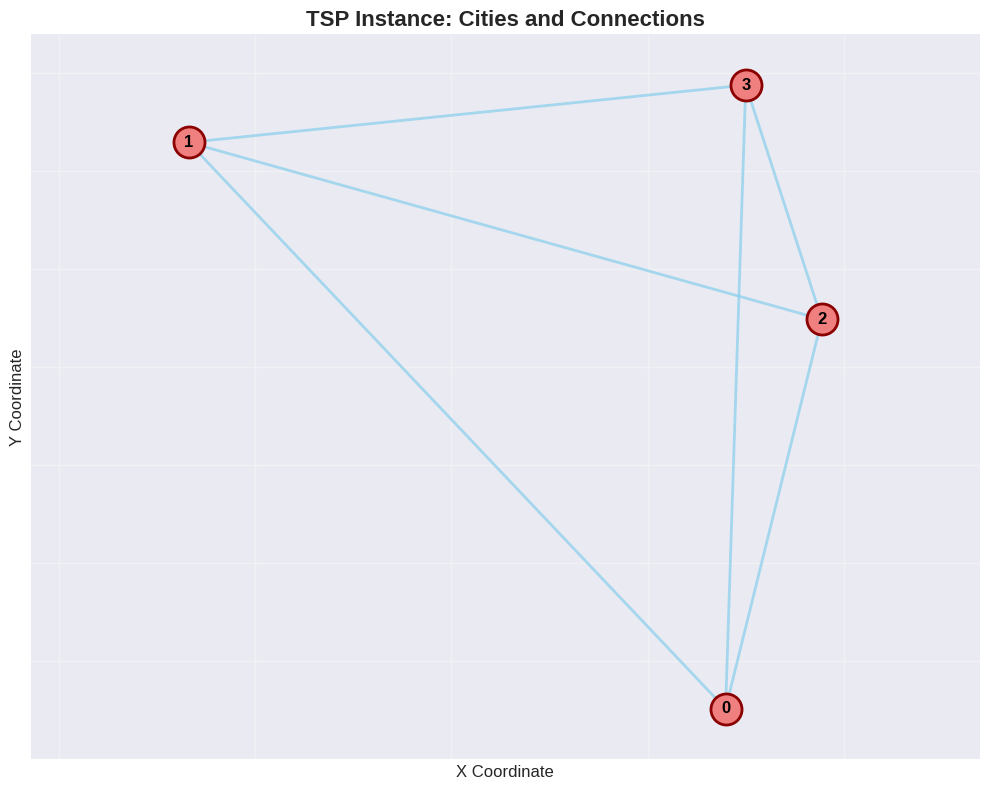

In [2]:
from tsp import TSPInstance

n_cities = 4  # Change this to the desired number of cities
tsp_instance = TSPInstance(n_cities)
print("Coordinates:")
print(tsp_instance.coords)
print("\nDistance Matrix:")
print(tsp_instance.og_dist_matrix)

# Plot the instance
tsp_instance.plot_tsp_instance()

In [3]:
# Classic solution

classic_route, classic_cost = tsp_instance.solve()
print("\nClassic Best Route Found:", classic_route)
print("Classic Minimum Cost of Best Route:", classic_cost)


Classic Best Route Found: [0, 1, 3, 2, 0]
Classic Minimum Cost of Best Route: 4.001257576150713


In [4]:
from bloch_sphere_encoding import BlochSphereEncoder

encoder = BlochSphereEncoder(tsp_instance)
bloch_tsp = encoder.get_encoded_instance()

print("\nDistance Matrix:")
print(tsp_instance.dist_matrix)


Distance Matrix:
[[0.         1.57079633 0.8073656  1.25610109]
 [1.57079633 0.         1.32324462 1.12719085]
 [0.8073656  1.32324462 0.         0.4959048 ]
 [1.25610109 1.12719085 0.4959048  0.        ]]


In [5]:
bloch_tsp.plot_all_cities_on_bloch_sphere()

In [6]:
bloch_tsp.plot_all_states_on_bloch_sphere()

In [7]:
routes = bloch_tsp.get_allowed_routes()
print("Allowed Routes:", len(routes))
#for route in routes:
#    print(route)

Allowed Routes: 6


In [8]:
best_route, min_cost, mean_error = bloch_tsp.solve_brute_force()

print("Best Route Found:", best_route)
print("Minimum Cost of Best Route:", min_cost)
print("Mean Error in Final States Across All Routes:", mean_error)

Best Route Found: (0, 1, 3, 2, 0)
Minimum Cost of Best Route: 4.001257576150713
Mean Error in Final States Across All Routes: 0.45349239820865433


In [9]:
# Compare with classic solution
classic_route, classic_cost = tsp_instance.solve()
print("\nClassic Best Route Found:", classic_route)
print("Classic Minimum Cost of Best Route:", classic_cost)
print("Quantum Best Route Found:", best_route)
print("Quantum Minimum Cost of Best Route:", min_cost)


Classic Best Route Found: [0, 1, 3, 2, 0]
Classic Minimum Cost of Best Route: 4.001257576150713
Quantum Best Route Found: (0, 1, 3, 2, 0)
Quantum Minimum Cost of Best Route: 4.001257576150713


In [10]:
from qiskit_ibm_runtime.fake_provider import FakeManilaV2

backend = FakeManilaV2()

In [11]:
backend_best_route, backend_min_cost, backend_mean_error = bloch_tsp.solve_brute_force(backend=backend)

print("Best Route Found:", backend_best_route)
print("Minimum Cost of Best Route:", backend_min_cost)
print("Mean Error in Final States Across All Routes:", backend_mean_error)

Best Route Found: (0, 1, 3, 2, 0)
Minimum Cost of Best Route: 4.001257576150713
Mean Error in Final States Across All Routes: 0.00849999999999862


In [12]:
# Compare with classic solution
classic_route, classic_cost = tsp_instance.solve()
print("\nClassic Best Route Found:", classic_route)
print("Classic Minimum Cost of Best Route:", classic_cost)
print("Quantum Best Route Found:", backend_best_route)
print("Quantum Minimum Cost of Best Route:", backend_min_cost)


Classic Best Route Found: [0, 1, 3, 2, 0]
Classic Minimum Cost of Best Route: 4.001257576150713
Quantum Best Route Found: (0, 1, 3, 2, 0)
Quantum Minimum Cost of Best Route: 4.001257576150713


In [13]:
#import sys
#!{sys.executable} -m lagrangeclient

In [14]:
import os
from iqm.qiskit_iqm import IQMProvider
# token has been automatically saved during previous steps of authentication
os.environ["IQM_TOKENS_FILE"] = "./tokens.json"
iqm_url = "https://spark.quantum.linksfoundation.com/"

# we get backend
provider = IQMProvider(iqm_url)
backend = provider.get_backend()

In [15]:
iqm_best_route, iqm_min_cost, iqm_mean_error = bloch_tsp.solve_brute_force(backend=backend)

print("Best Route Found:", iqm_best_route)
print("Minimum Cost of Best Route:", iqm_min_cost)
print("Mean Error in Final States Across All Routes:", iqm_mean_error)

Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

Best Route Found: (0, 1, 3, 2, 0)
Minimum Cost of Best Route: 4.001257576150713
Mean Error in Final States Across All Routes: 0.0028877834751673457


In [16]:
# Compare with classic solution
classic_route, classic_cost = tsp_instance.solve()
print("\nClassic Best Route Found:", classic_route)
print("Classic Minimum Cost of Best Route:", classic_cost)
print("Quantum Best Route Found:", iqm_best_route)
print("Quantum Minimum Cost of Best Route:", iqm_min_cost)


Classic Best Route Found: [0, 1, 3, 2, 0]
Classic Minimum Cost of Best Route: 4.001257576150713
Quantum Best Route Found: (0, 1, 3, 2, 0)
Quantum Minimum Cost of Best Route: 4.001257576150713
